# **Sequential Decision-Making and $Q$-Learning**

Imagine a small delivery robot moving through a building. It starts in a hallway, chooses where to move, receives feedback, and must learn to reach a charging station while avoiding blocked areas. It is not given the route in advance; it learns from repeated attempts.

This is a simplified model of problems such as robot navigation, game-playing, and adaptive resource control. We will first build the mathematical model, then implement a small grid example in Python using only lists, dictionaries, and loops.

## **1. Model the robot's decisions mathematically**

At each time step $t$, the robot observes where it is, chooses a move, receives a reward, and arrives at a new location:

$$s_t \xrightarrow{a_t,\ r_{t+1}} s_{t+1}.$$

A **Markov decision process (MDP)** is described by:

$$\mathcal{M} = \langle \mathcal{S}, \mathcal{A}, T, R, \gamma \rangle.$$

- $\mathcal{S}$ is the set of possible **states**. Here, a state is the robot's grid location.
- $\mathcal{A}$ is the set of possible **actions**, such as moving up, down, left, or right.
- $T(s,a,s')$ is the **transition model**: the probability that action $a$ in state $s$ leads to state $s'$. In our grid, transitions are deterministic.
- $R(s')$ is the immediate **reward** for arriving in state $s'$. In this grid, the goal state gives $+10$ and every other state gives $-1. For this grid, the reward is written on arrival: $r_{t+1}=R(s_{t+1})$.
- $\gamma \in [0,1]$ is the **discount factor**: it controls how much future rewards count compared with immediate rewards.

The notation $\pi(a \mid s)$ means the probability of choosing action $a$ given state $s$. A policy is the rule the agent uses to choose actions; for a deterministic policy, it always chooses the same action in a given state. The goal is to learn a policy that produces high total reward.

**Definition (Markov property).** The current state contains the information from the past needed to predict the next state. Once the current state and action are known, the earlier history does not change the transition probabilities.

$$P(S_{t+1}=s' \mid S_0,A_0,R_1,\ldots,S_t=s,A_t=a) = P(S_{t+1}=s' \mid S_t=s,A_t=a).$$


The interaction sequence can be written as:

$$\tau = (s_0,a_0,r_1,s_1,a_1,r_2,s_2,\ldots).$$

Q-learning updates from individual transitions in this sequence, while the objective is to maximize the discounted return accumulated over time.


## **2. What is Q-learning trying to learn?**

Recall that a **policy** $\pi(a \mid s)$ specifies how the agent chooses an action in each state. Q-learning aims to find a policy that maximizes the **expected discounted return**.

Starting at time $t$, the discounted return is the reward now plus the discounted rewards that follow:

$$G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1}.$$

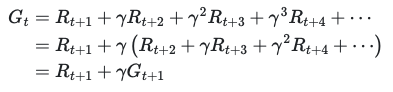

$G_t$ is the total discounted return for one possible sequence of future rewards. A **value** is not that single sequence's return: it is the expected return over possible future sequences under a policy. They have the same units (reward), but $G_t$ describes one outcome while a value summarizes possible outcomes. An **action-value function** is a rule that assigns such a number to each state-action pair: in plain words, it says how much return to expect after starting in state $s$, choosing action $a$ first, and then following policy $\pi$.

Here, $s$ is the current state, $a$ is the first action chosen, and $\pi$ is the policy followed afterward. The notation $\mathbb{E}_\pi$ means the expected value, or average across possible outcomes, weighted by their probabilities under policy $\pi$. The conditional bar $\mid$ means “given”: we condition on being in state $s$ and taking action $a$.

With these definitions, the action-value function is:

$$Q^\pi(s,a)=\mathbb{E}_\pi[G_t \mid S_t=s,A_t=a].$$

Q-learning seeks the **optimal action values** $Q^*(s,a)$. The star means the best expected return for each state-action pair when the agent acts optimally afterward. The Q table holds current estimates of these unknown optimal values; it does not know them exactly at the start.

The Q table has one row per state and one column per action; each cell stores one estimate. Before learning begins, every action-value estimate starts at zero:

$$Q(s,a)=0 \quad \text{for all } (s,a) \in \mathcal{S} \times \mathcal{A}.$$

These are starting estimates, not learned preferences. Learning changes these estimates from experience; it does not write a route into the table.



### **One training step**

The agent observes one transition: current state $s_t$, chosen action $a_t$, reward $r_{t+1}$, and next state $s_{t+1}$. For a non-terminal next state, the **one-step target** is the observed reward plus the best future value currently estimated in the Q table:

$$y_t = r_{t+1} + \gamma \max_{a' \in \mathcal{A}(s_{t+1})} Q(s_{t+1},a').$$

Here, $a'$ is a candidate action available at the next state; the prime is just a label distinguishing it from the action already taken, not a derivative. Reading max means calculate the current Q estimate for each available next action and keep the largest. $Q$ is the current learned estimate, whereas $Q^*$ is the ideal optimal value; the target uses $Q$ because $Q^*$ is not known during learning.

The $\gamma$ is the same discount factor as in the return formula. The immediate reward $r_{t+1}$ is not discounted; the next-state Q estimate represents future return, so it is multiplied by $\gamma$. This matches the recursive return relation $G_t=r_{t+1}+\gamma G_{t+1}$.

The **temporal-difference (TD) error** is target minus the old estimate:

$$\delta_t = y_t - Q(s_t,a_t).$$

The Q-learning update moves that one table entry toward the target:

$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha\delta_t,$$

Read the update as: **new estimate = old estimate + $\alpha$ times the TD error**. The step size $\alpha$ is the fraction of the gap between the old estimate and the target corrected in this update: with $\alpha=0.2$, move 20% of the gap; with $\alpha=1$, move all the way to the target. If $\delta_t$ is positive, the target is greater than the old estimate, so the positive correction makes $Q$ increase. If $\delta_t$ is negative, the target is smaller, so the negative correction makes $Q$ decrease. If $\delta_t=0$, there is no change. This is error in the value estimate, not an error in the reward or environment. For example, with old estimate $2$ and $\alpha=0.2$: target $5$ gives $\delta=+3$ and new estimate $2.6$, while target $-1$ gives $\delta=-3$ and new estimate $1.4$. The grid example below demonstrates the negative case.

The target is not computed by evaluating every possible route. At each step, the agent uses the reward and next state it observed, together with its current Q estimates. As those estimates change, later targets change too.

### **One transition, one table update**

At the beginning, every Q-table entry is $0$. Suppose the agent is at $s_t=(0,0)$, chooses $a_t=\text{right}$, moves to $s_{t+1}=(0,1)$, and receives $r_{t+1}=-1$. Since all Q values at $(0,1)$ are $0$:

$$y_t = -1 + 0.95 \max_{a' \in \mathcal{A}((0,1))}Q((0,1),a') = -1 + 0.95(0) = -1.$$

The old estimate is $Q((0,0),\text{right})=0$, so $\delta_t=-1-0=-1$. With $\alpha=0.2$:

$$Q((0,0),\text{right}) \leftarrow 0 + 0.2(-1) = -0.2.$$

Only this state-action entry changes in this update. Later experiences update other entries; the greedy policy then chooses the highest-Q action in the current state. The route is produced by these choices, not memorized as a fixed path.

For the connection between this update and the Bellman equation, see “Where to go next?” at the end of the activity.

## **3. Translate the scenario into a small grid**

We will use a $4 \times 4$ grid. A state is a pair $(row, column)$, with both coordinates starting at 0. The robot starts at the upper-left cell and must reach the lower-right goal cell. Two cells are blocked.

The grid is small enough to inspect directly. `S` is the start, `G` is the goal, `#` is a blocked cell, and `.` is an open cell.

In [3]:
import random

SIZE = 4 # Size of the grid (4x4)
START = (0, 0) # Starting position of the agent
GOAL = (3, 3) # Goal position of the agent
WALLS = {(1, 1), (2, 1)} # Positions of walls in the grid

# Each action is a change in (row, column).
ACTIONS = [(0, 1), (1, 0), (0, -1), (-1, 0)] # right, down, left, up
ACTION_NAMES = ["right", "down", "left", "up"] # Names corresponding to the actions

STATES = [
    (row, column) # All possible states in the grid, excluding walls
    for row in range(SIZE) # Iterate over all rows
    for column in range(SIZE) # Iterate over all columns
    if (row, column) not in WALLS # Exclude wall positions
]

# Print the grid world 
for row in range(SIZE): # Iterate over each row in the grid
    cells = [] # Initialize a list to hold the cell representations for the current row
    for column in range(SIZE): # Iterate over each column in the grid
        position = (row, column) # Get the current position in the grid
        if position == START: # 
            cells.append("S")
        elif position == GOAL:
            cells.append("G")
        elif position in WALLS:
            cells.append("#")
        else:
            cells.append(".")
    print(" ".join(cells)) # Print the current row of the grid world, joining the cell representations with spaces

S . . .
. # . .
. # . .
. . . G


In [11]:
# Print the list of states in the grid world, excluding walls:
print("States:", STATES) # Print the list of states in the grid world, excluding walls
print() # Print a blank line for better readability

# Print the list of actions available to the agent, along with their corresponding changes in position:
for action, name in zip(ACTIONS, ACTION_NAMES): # Iterate over each action and its corresponding name
    print(f"{name}: {action}") # Print the action name and its change in position

States: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 3), (2, 0), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3)]

right: (0, 1)
down: (1, 0)
left: (0, -1)
up: (-1, 0)


### **3.1 Define what one move does**

An action changes the row and column. For example, moving right adds $(0,1)$ to the current position. The transition function below:
- applies the move, 
- keeps the robot inside the grid, and 
- prevents it from entering a wall.

For feedback, each ordinary move has reward $-1$ and reaching the goal has reward $+10$. The small step cost encourages shorter routes.

In [ ]:
def step(state, action, step_reward=-1): # step_reward=-1 encourages the agent to reach the goal in fewer steps
    row, column = state
    row_change, column_change = action

    candidate = (
        max(0, min(SIZE - 1, row + row_change)),
        max(0, min(SIZE - 1, column + column_change)),
    )

    # A wall blocks movement, so the robot stays in its current cell.
    next_state = state if candidate in WALLS else candidate
    done = next_state == GOAL
    reward = 10 if done else step_reward
    return next_state, reward, done

### **3.2 Store the $Q$ estimates**

Each open cell is a state. For every state, we store one number per action. At the beginning, all estimates are zero because the robot has not learned anything yet.

The list order matches `ACTIONS`: right, down, left, up. The helper `choose_action` implements the $\epsilon$-greedy rule from the mathematical section.

**Tie-breaking note:** Initially all actions tie at zero. In this implementation, when epsilon-greedy exploits, Python `max` picks the first action in `ACTIONS` (`right`); with epsilon=0.2, it instead chooses a random action 20% of the time. Thus `right` is a tie-breaking artifact, not a learned preference.

In [3]:
q_values = {state: [0.0] * len(ACTIONS) for state in STATES}


def choose_action(state, epsilon):
    if random.random() < epsilon:
        return random.randrange(len(ACTIONS))
    return max(range(len(ACTIONS)), key=lambda index: q_values[state][index])


print("Number of states:", len(q_values))
print("Actions per state:", len(ACTIONS))

Number of states: 14
Actions per state: 4


## **4. Train the robot with Q-learning**

Each training step follows the same sequence as the update equation:

1. Choose an action using $\epsilon$-greedy exploration.
2. Observe the next state, reward, and whether the goal was reached.
3. Compute the target $y_t$.
4. Compute the temporal-difference error $\delta_t = y_t - Q(s_t,a_t)$.
5. Update only the value for the state-action pair that was just tried.

The code below uses $\alpha=0.2$, $\gamma=0.95$, and $\epsilon=0.2$. A fixed random seed makes the classroom run reproducible. Rerunning the training cell resets the Q values and random seed, so each experiment starts from the same conditions.


In [4]:
random.seed(7)

alpha = 0.2
gamma = 0.95
epsilon = 0.2
step_reward = -1
number_of_episodes = 1000
max_steps_per_episode = 40

q_values = {state: [0.0] * len(ACTIONS) for state in STATES}

for episode in range(number_of_episodes):
    state = START

    for step_number in range(max_steps_per_episode):
        action_index = choose_action(state, epsilon)
        action = ACTIONS[action_index]
        next_state, reward, done = step(state, action, step_reward)

        if done:
            target = reward
        else:
            target = reward + gamma * max(q_values[next_state])

        old_estimate = q_values[state][action_index]
        td_error = target - old_estimate
        q_values[state][action_index] = old_estimate + alpha * td_error

        state = next_state
        if done:
            break

print("Training complete.")


Training complete.


## **5. Test the learned policy**

Training explores and updates the table. To test what was learned, we now stop exploration and always choose the action with the largest stored $Q$ value. The route is a sequence of grid coordinates.

In [5]:
state = START
print("Q values at START (right, down, left, up):", q_values[START])
greedy_start_action = max(range(len(ACTIONS)), key=lambda index: q_values[START][index])
print("Greedy action at START:", ACTION_NAMES[greedy_start_action])
route = [state]

for _ in range(SIZE * SIZE * 2):
    if state == GOAL:
        break

    action_index = max(range(len(ACTIONS)), key=lambda index: q_values[state][index])
    next_state, reward, done = step(state, ACTIONS[action_index])
    state = next_state
    route.append(state)

    if done:
        break

reached_goal = route[-1] == GOAL
print("Greedy route:", route)
print("Number of moves:", len(route) - 1)
print("Reached goal:", reached_goal)
assert reached_goal
assert not any(position in WALLS for position in route)

route_cells = set(route)
for row in range(SIZE):
    cells = []
    for column in range(SIZE):
        position = (row, column)
        if position == START:
            cells.append("S")
        elif position == GOAL:
            cells.append("G")
        elif position in WALLS:
            cells.append("#")
        elif position in route_cells:
            cells.append("*")
        else:
            cells.append(".")
    print(" ".join(cells))

Greedy route: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (3, 3)]
Reached goal: True
S * * *
. # . *
. # . *
. . . G


### **Interpret the result**

The printed route is generated from the learned $Q$ table; it was not written into the program as a sequence of directions. `S` marks the start, `G` the goal, `#` a wall, and `*` a cell visited by the greedy policy.

The step reward is $-1$, so each extra move reduces the return. Reaching the goal gives $+10$. During training, $\epsilon=0.2$ means the robot usually follows its current best estimate but sometimes tries a random action.

**Check your understanding:**

1. Why does the update target equal only the reward when `done` is true?
2. Why do we reset the Q table before comparing two experiments?
3. What might happen if $\epsilon=0$ before the robot has discovered the goal?

## **6. Lab: run a controlled experiment**

Use this repeatable protocol for every trial: set one variable, rerun the Section 4 training cell (it resets Q values and reseeds the random generator), then rerun Section 5. Record the printed Q values at START, greedy action, route length, and whether the goal was reached. The outputs from Section 5 are the comparison evidence; Section 4 handles resetting between runs.

### **Tasks**

1. Compare $\epsilon=0.0$, $0.2$, and $0.5$. Record the Q values at START, greedy action, route length, and goal result. In this grid, even $\epsilon=0$ reaches the goal: explain how the first-action tie-breaking and zero-valued untried actions affect the sequence of choices. Why does this not guarantee reliable discovery in every environment?
2. With $\epsilon=0.2$ held fixed, change `step_reward` in the Section 4 cell from $-1$ to $-2$. Compare the Q values and route. Does the route change here? Explain why a larger step cost lowers returns, and what kind of environment would make the shorter-route preference visible.
3. Add a wall at `(1, 2)` while keeping a path to the goal, then rerun training and test the learned route.


In [5]:
# Experiment: add one wall that still leaves a route to the goal.
WALLS.add((1, 2))

# Rebuild the state space after changing the environment.
STATES = [
    (row, column)
    for row in range(SIZE)
    for column in range(SIZE)
    if (row, column) not in WALLS
]
print("Open states:", len(STATES))
# Rerun Sections 4 and 5 to retrain and test with this changed state space.


Open states: 13


## **7. Exit ticket and further reading**

Submit the transition function, the training loop, and the greedy route produced by your agent. In a short explanation, define $s$, $a$, $r$, $\gamma$, $\alpha$, and $\epsilon$, then describe how one observed transition changes one entry in the Q table.

**Extension:** make one action occasionally move in a random direction. Explain how this changes the transition model $P(s' \mid s,a)$ and why the agent may need more training.

### **Further reading**

Russell and Norvig, *Artificial Intelligence: A Modern Approach*, 4th edition:

- **Chapter 17, Section 17.1, “Sequential Decision Problems”**: states, actions, rewards, policies, and discounted utility over time. Read **17.1.1, “Utilities over Time,”** for the role of $\gamma$, and **17.1.4, “Representing MDPs,”** for the MDP model.
- **Chapter 22, Section 22.1, “Learning from Rewards”**: the basic reinforcement-learning setting and value estimates.
- **Chapter 22, Section 22.2.3, “Temporal-Difference Learning”**: the target and prediction-error idea behind the update.
- **Chapter 22, Section 22.3.1, “Exploration”**: why the agent must sometimes try actions it does not currently prefer.
- **Chapter 22, Section 22.3.3, “Temporal-Difference Q-learning”**: the Q-learning update rule used in this notebook.

### **A note on stochastic processes and deep Q-learning**

An MDP can have stochastic transitions: the same state-action pair may lead to different next states with different probabilities. The grid in this notebook is deterministic, so it illustrates the Q-learning update without exploring stochastic transition models in depth.

This notebook uses **tabular Q-learning**, storing one value for each state-action pair. **Deep Q-Networks (DQN)** use a neural network to approximate the Q function when a table is impractical. DQN builds on Q-learning but is outside the scope of this notebook.

### **Where to go next?**

The Bellman optimality equation describes the ideal action values when the transition model is known:

$$Q^*(s,a) = \sum_{s'} T(s,a,s') \left[R(s') + \gamma \max_{a'}Q^*(s',a')\right].$$

Russell and Norvig, *Artificial Intelligence: A Modern Approach*, 4th edition, Sections 17.2.1 and 22.3.3, distinguish **value iteration**, which applies Bellman backups using a known model, from **Q-learning**, which updates estimates from observed transitions. In that terminology, Q-learning is **off-policy** because its target uses the best estimated next action, and it **bootstraps** because it uses a current Q estimate for future value. These ideas extend the activity but are not required to run the lab.